In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

import psycopg
from psycopg.rows import dict_row
from langgraph.checkpoint.postgres import PostgresSaver
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
def get_database_url():
    database_url = os.getenv("DATABASE_URL")

    if not database_url:
        raise ValueError(
            "DATABASE_URL is missing. Please add your Render PostgreSQL External Database URL to .env"
        )

    if "sslmode=" not in database_url:
        separator = "&" if "?" in database_url else "?"
        database_url = f"{database_url}{separator}sslmode=require"

    return database_url

In [3]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise ValueError(
        "OPENAI_API_KEY is missing. Please add your OpenAI API key to .env"
    )

In [4]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [5]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [6]:
class State(TypedDict):
    topic: str
    plan: Plan
    # redcuer: results form workers get concatenated automatically
    sections: Annotated[list[str], operator.add]
    final: str

In [7]:
llm = ChatOpenAI(
    model="gpt-5-mini",
    api_key=OPENAI_API_KEY
)

In [8]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [9]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
    for task in state["plan"].tasks]

In [10]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [11]:
from pathlib import Path
import re

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # Create a safe filename
    safe_title = re.sub(r'[<>:"/\\|?*]', '', title)
    safe_title = safe_title.lower().replace(" ", "_")

    filename = f"{safe_title}.md"
    output_path = Path(filename)

    # Save Markdown file
    output_path.write_text(final_md, encoding="utf-8")

    print(f"Saved as: {output_path.resolve()}")

    return {"final": final_md}

In [12]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

In [13]:
# =========================
# PostgreSQL Checkpointer
# =========================
DATABASE_URL = get_database_url()

_conn = psycopg.connect(
    DATABASE_URL,
    autocommit=True,
    row_factory=dict_row
)

checkpointer = PostgresSaver(_conn)
checkpointer.setup()

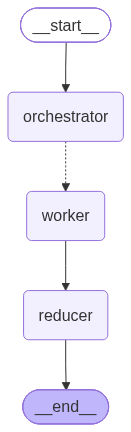

In [14]:
app = g.compile(checkpointer=checkpointer)

app

In [15]:
config = {
        "configurable": {
            "thread_id": "test_thread_id"
        }
    }

In [18]:
out = app.invoke(
    {
        "topic": "Write a comprehensive blog on Deep Learning",
        "sections": []
    },
    config=config
)

Saved as: C:\Users\sudee\OneDrive\Desktop\agent_writer\AgentWriter-AI\notebooks\deep_learning_a_comprehensive_guide.md


In [17]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: Intuition, Math, Implementation, and Applications', tasks=[Task(id=1, title='Introduction: What is Self-Attention and Why It Matters', brief='Define self-attention at a high level; contrast with recurrence and convolution; explain its role as the core building block of Transformers and why it revolutionized sequence modeling.'), Task(id=2, title='Intuition: How Self-Attention Works', brief='Use a simple, non-technical example (e.g., reading a sentence) to illustrate how a token attends to others; explain the roles of queries, keys, and values and the concept of weighted information aggregation.'), Task(id=3, title='Mathematical Formulation: Scaled Dot-Product Attention', brief='Present the equations for attention scores, scaling, softmax normalization, and the final weighted sum; explain causality/masking for decoder use and the importance of numerical stability.'), Task(id=4, title='Mul